# Global and localized learned controllers

`FIGURES_RL.ipynb` trains one learned controller **per household**, on that
household's two training years alone. This notebook asks what changes when the
controllers are trained on **many** households — one global network, or networks
localised to a type of consumer — and where the result lands against the MILP,
the MPC and the best rule. Everything is priced by `hs.summarize`, the study's
own accounting, so a pooled row, a local row, a rule and the MILP are directly
comparable.

### How the pooled and localised models are built

Every model below is the same learner as the local one (`rl_global` is a pooled
port of `rl_control`; a one-household pool reproduces `rl_control.train_dqn` bit
for bit), with the same features (`fc_h24`: causal 14-day-median forecast,
published day-ahead prices, 24 h lookahead, SI contract state), the same
hyperparameters — the joint search's winners (`run_rl_benchmark.TUNED`, promoted
2026-10-08, `FIGURES_RL_HPO.ipynb`), tuned for the LOCAL learner and not re-tuned for
pooling — the same behaviour-cloning optimiser (class weighting, label smoothing,
batch, patience: `run_rl_benchmark.effective_clone`, also inside every monthly
re-clone), and the same three-way split applied to **every**
household in a pool: train = days 0–730 minus every 5th week, validation = those
20 weeks, test = days 730–1095 of the 30 study households only, read once by
`run_policy`. Pooling other homes' training years cannot leak the test year.
299 of the 300 Ausgrid households are usable (Ausgrid 2 has an 81-day gap).

| scheme | localisation | data each network sees | how the network knows the type |
|---|---|---|---|
| **local** | to the household | 1 household | it is the only one |
| **global** | none | 299 households | it does not |
| **global + shape-type input** | by input | 299 households | one-hot of the k=30 cluster appended to the observation (not normalised) |
| **per shape type** | by data | the cluster's 1–26 members | separate network per cluster |
| **per shape sub-type** | by data | 3–11 households (KMeans inside a cluster of ≥ 8, on training-year profiles) | separate network |
| **global, fine-tuned per shape type** | by fine-tuning | 299, then the cluster's members | the global-typed weights and scaler, trained on in the type |
| **random pool, shape-type sizes** | none — a *control* | the study household + as many random households as its cluster has members | — |
| **per control type** | by data | ~50 households (k=6) | separate network |
| **global, fine-tuned per control type** | by fine-tuning, with a fallback guard | 299, then the type's members | the global weights; the fine-tune is kept only where it beats them on the type's validation |
| **global, fine-tuned per season** | in time, by fine-tuning | 299 households' training days of one season | four networks, switched at the season boundary |
| **global, re-fine-tuned monthly** | in time, to the household's own recent past | the household's last 8 weeks before each test month | twelve networks, one per test month |

**Shape types** are the study's k=30 clustering (`Clustering/Ausgrid/…_30.csv`):
the 72-value weekly load profile, each household normalised by its own maximum,
so shape and nothing else. The 30 study households are the rank-1 member of each.
**Control types** are k=6 clusters on what a battery's dispatch actually depends
on — log annual load and PV-to-load ratio — measured on the training years only.

**Fine-tuning** continues from the global network: a clone at 0.3 × the learning
rate, early-stopped on the type's held-out loss, and kept as the global clone if
that loss never improves; a DQN under the warm-start protection (ε 0.2, half rate),
`bc_dqn` held to the type-localised clone. For control types the DQN fine-tune also
treats the global network as its first candidate, so it cannot hand back weights
that are worse on the type's validation weeks than those it started from.

**Every model here was retrained under those settings on 2026-10-08/09**; the
version of this study under the previous settings is in git (commit `7c9e83cd`).
Several of its conclusions did not survive the retune, and the text below says
where.

**Seeds.** A global network drives all 30 households, so its training-seed luck
does not average out across them as 30 local networks' does. The global schemes
were trained under three seeds and are **averaged per household**; every other
scheme is one seed. The local clone was re-trained under two extra seeds as a noise
floor (§2).

In [1]:
import importlib, json, os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon, spearmanr

import hems_study as hs
import figure_style as fs
import run_rl_benchmark as rb
import run_rl_global as rgg
import pv_split as ps
hs, fs, rb, rgg, ps = (importlib.reload(m) for m in (hs, fs, rb, rgg, ps))

import Plotting_Functions as pf
pf = importlib.reload(pf)
pf.use(subdir="hems", titles=False)
from Plotting_Functions import INK, INK_2, MUTED, SURFACE, SERIES, PLAIN, PCT, finish

# ---- the study's own frame: rules, MILP family, local learners, pooled ones ----
# Every row goes through `hs.summarize` unchanged, so a pooled model, a local
# one, a rule and the MILP are priced by the same accounting: the bill (plus,
# on SI, the standing charge on the contract the controller's own peaks
# agreed), the pack as an NPV at 5 % over min(12 y, 6000 EFC).
df_study = hs.collect_results()
MPC_BEST_ARM = {t: hs.best_mpc_arm(df_study, t) for t in hs.REFERENCE_ARM}
wide = hs.merge_best_mpc(df_study, MPC_BEST_ARM)
wide = wide[wide.arm.isin(hs.REFERENCE_ARM.values())].reset_index(drop=True)
wide = hs.merge_learned_controllers(
    wide, controllers=[(m, "fc_h24") for m in rgg.METHODS], verbose=False)
POOLED = ("global", "global_typed", "type", "rand_type", "global_ft", "subtype",
          "ctrl_type", "ctrl_ft", "season_ft", "roll_ft")
# The monthly re-fit's window x check grid (§5b): every (window, guard) but the
# first run's (56 d, weak), which is `roll_ft`.
ROLL_GRID = [(w, g) for w in rgg.ROLL_WINDOWS for g in rgg.ROLL_GUARDS]
POOLED = POOLED + tuple(rgg.roll_scheme(w, g) for w, g in ROLL_GRID
                        if (w, g) != (56, "weak"))
wide = rgg.merge_pooled(wide, POOLED)
long = hs.summarize(wide)
long["ident"] = long["dataset"].str.split().str[-1].astype(int)
TARIFFS = ("AU", "SI")

# ---- names ----
METHOD_NAME = {"bc": "IL", "bc_dqn": "IL+RL", "dqn": "RL"}
SCHEME_NAME = {
    "fc_h24": "per household (local)",
    "global": "global, 299 households",
    "global_typed": "global + shape-type input",
    "type": "per shape type (k=30)",
    "rand_type": "random pool, shape-type sizes",
    "global_ft": "global, fine-tuned per shape type",
    "subtype": "per shape sub-type",
    "ctrl_type": "per control type (k=6)",
    "ctrl_ft": "global, fine-tuned per control type",
    "season_ft": "global, fine-tuned per season",
    "roll_ft": "global, re-fine-tuned monthly on own last 8 weeks",
    **{rgg.roll_scheme(w, g): f"global, re-fit monthly on own last {w} d, "
                              f"{'strict' if g == 'strong' else 'simple'} check"
       for w in rgg.ROLL_WINDOWS for g in rgg.ROLL_GUARDS if (w, g) != (56, "weak")},
}


def split_learned(c):
    """'bc_dqn_global_typed' -> ('bc_dqn', 'global_typed'), else None."""
    for m in ("bc_dqn", "dqn", "bc"):
        if c.startswith(m + "_") and c[len(m) + 1:] in SCHEME_NAME:
            return m, c[len(m) + 1:]
    return None


# The best rule is picked per tariff ex post, on the median net saving of the
# scored year -- the same convention `best_mpc_arm` uses for the MPC. An ex-post
# best of seven favours the rule, which is the conservative direction for any
# claim that a learner beats it. `price_oracle` reads the whole year's prices
# (a diagnostic, never deployable) and is excluded.
def best_rbc(tariff):
    sub = long[(long.tariff == tariff)
               & long.controller.map(lambda c: fs.ctrl_family(c) == "RBC")
               & ~long.controller.isin(["price_oracle", "no_battery"])]
    return sub.groupby("controller")["saving_annual_net"].median().idxmax()


BEST_RBC = {t: best_rbc(t) for t in TARIFFS}


def label(c, tariff):
    s = split_learned(c)
    if s:
        return f"{METHOD_NAME[s[0]]}, {SCHEME_NAME[s[1]]}"
    if c == "milp_full":
        return "MILP, full year, perfect foresight"
    if c == "oracle":
        return "MPC 24 h, perfect forecast"
    if c == "mpc_best":
        kind = hs.forecaster_kind_of(MPC_BEST_ARM[tariff])
        return f"MPC 24 h, {ps.forecast_label(kind)} (best realistic)"
    if c == BEST_RBC[tariff]:
        return f"{hs.controller_label(c, 48)} (best RBC)"
    return hs.controller_label(c, 48)


REFS = lambda t: ["milp_full", "oracle", "mpc_best", BEST_RBC[t]]
print("best RBC:", BEST_RBC, "| best realistic MPC:",
      {t: hs.forecaster_kind_of(a) for t, a in MPC_BEST_ARM.items()})
# `wear_eur` is the life-limited wear `summarize` charges -- zero unless the
# cycling would end the pack before its 12-y calendar life. (`wear_shadow_eur`
# is the dispatch price, reported and never billed.)
print("pack priced as NPV; rows whose cycling ends the pack early:",
      int((long["wear_eur"].fillna(0) > 0).sum()))

/Users/summerscholl/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  mpc_best: AU <- AU_H24_hbd_median14 (hbd_median14), 30 row(s)
  mpc_best: SI <- SI_H24_hbd_median14 (hbd_median14), 30 row(s)


pooled controllers joined (seeds averaged): bc_global x3, dqn_global x3, bc_dqn_global x3, bc_global_typed x3, dqn_global_typed x3, bc_dqn_global_typed x3, bc_type x3, dqn_type x1, bc_dqn_type x1, bc_rand_type x1, bc_global_ft x1, dqn_global_ft x1, bc_dqn_global_ft x1, bc_subtype x1, dqn_subtype x1, bc_dqn_subtype x1, bc_ctrl_type x1, dqn_ctrl_type x1, bc_dqn_ctrl_type x1, bc_ctrl_ft x1, dqn_ctrl_ft x1, bc_dqn_ctrl_ft x1, bc_season_ft x3, dqn_season_ft x3, bc_dqn_season_ft x3, bc_roll_ft x3, dqn_roll_ft x3, bc_dqn_roll_ft x3, bc_roll_w56_strong x3, dqn_roll_w56_strong x3, bc_dqn_roll_w56_strong x3, bc_roll_w112_weak x3, dqn_roll_w112_weak x3, bc_dqn_roll_w112_weak x3, bc_roll_w112_strong x3, dqn_roll_w112_strong x3, bc_dqn_roll_w112_strong x3, bc_roll_w168_weak x3, dqn_roll_w168_weak x3, bc_dqn_roll_w168_weak x3, bc_roll_w168_strong x3, dqn_roll_w168_strong x3, bc_dqn_roll_w168_strong x3
best RBC: {'AU': 'price_rank_daily', 'SI': 'self_consumption_peak_shaving'} | best realistic MPC: {

## 1. Where the pooled controllers land

Against the full-year MILP (perfect foresight over the whole year), the 24 h MPC
on a **perfect** forecast, the 24 h MPC on the **best realistic** forecast
(`hems_study.best_mpc_arm`: the deployable forecast arm with the best median net
saving, `hbd_median14` on both tariffs), and the **best rule** (picked the same
way, ex post, so the comparison favours the rule). The axis is the battery's
lifetime NPV; the table below adds the mean net saving per year, its share of the
MILP's, and paired win counts.

**AU.** The pooled clones now **beat the best rule**: the global clone saves 268.9
AUD/a (94.7 % of the MILP's 283.9) and the clone per control type 269.3 (94.9 %),
against 264.5 for `price_rank_daily`, which they beat on 25 and 27 of 30 households.
The tuned local clone saves 261.4 (92.1 %, beats the rule on 11 of 30). Every learned
clone beats the best realistic MPC (187) on all 30 households; only the MILP and the
perfect-forecast MPC (283) are clearly above them.

**SI.** The global clone and the clones derived from it save 61–64 EUR/a (57–59 % of
the MILP's 108; best: the global clone re-fitted monthly on the household's own
recent days, 64.3), up from 54.5 for the local clone, and beat the best realistic MPC
(32) on 29–30 of 30 households —
but stay short of the best rule, `self_consumption_peak_shaving` (72), which they beat
on 3–5 of 30, and of the perfect-forecast MPC (74). The SI gap to the rule is not about
pooling: the training reward prices energy and excess power but not the standing
charge on the agreed kW, which is where SI's money is (`FIGURES_RL.ipynb` §6).

Pure RL is the exception throughout: pooled DQN saves less than local DQN on both
tariffs (global 217.8 against 235.5 AUD/a; 34.4 against 47.0 EUR/a).

findfont: Failed to find font weight semibold, now using 700.


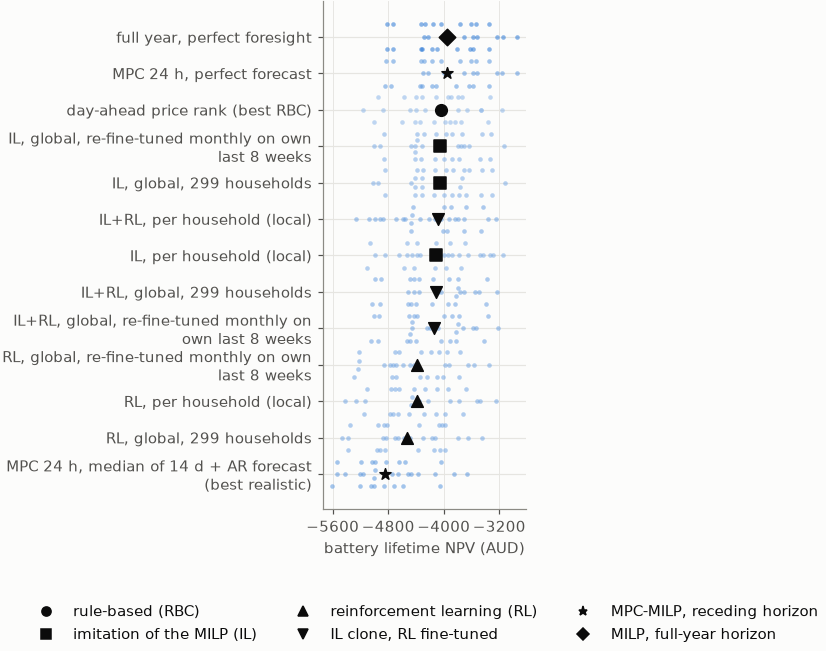

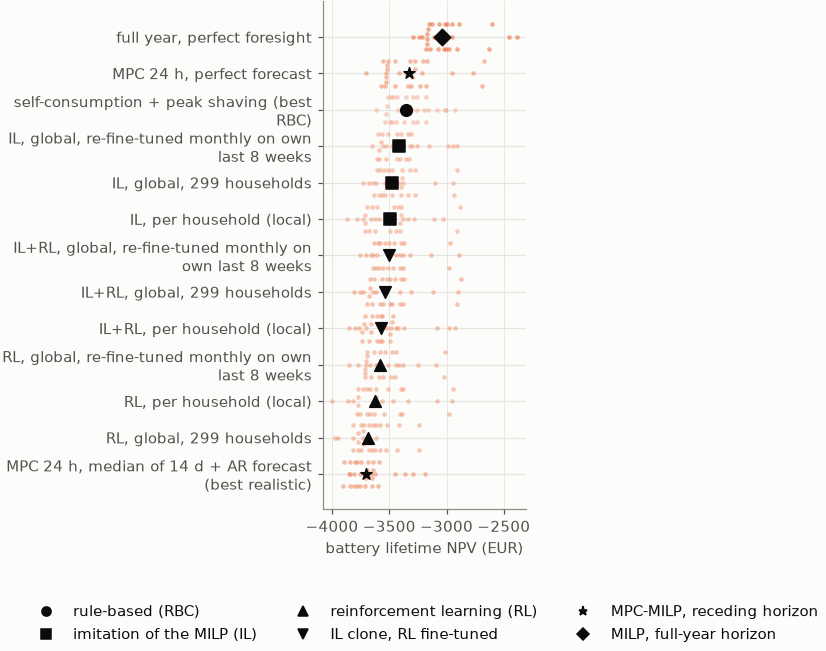

In [2]:
# Ranked on the study's axis, the lifetime NPV of the battery. One figure per
# tariff (a shared row would give each ranking half a column). The learned rows
# shown are the deployable ones a reader would choose between: the local model,
# the global one, and the control-type localisation with its fallback guard.
SHOW = ["fc_h24", "global", "roll_ft"]
for tariff in TARIFFS:
    rows = REFS(tariff) + [f"{m}_{s}" for m in ("bc", "bc_dqn", "dqn") for s in SHOW]
    sub = long[(long.tariff == tariff) & long.controller.isin(rows)]
    order = (sub.groupby("controller")["npv"].median().sort_values()
             .index.tolist())
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.85))
    for row, c in enumerate(order):
        v = sub.loc[sub.controller == c, "npv"].to_numpy()
        ax.scatter(v, row + fs.beeswarm(v), s=9, alpha=0.55, linewidths=0,
                   color=fs.ctrl_color(tariff, c), zorder=2)
        ax.scatter([np.median(v)], [row], marker=fs.ctrl_marker(c), s=58,
                   color=INK, zorder=3)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([fs.tick_label(c, {c: label(c, tariff)}, width=40)
                        for c in order])
    # Five-digit tick labels on a narrow axis run into each other at 5.
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    fams = [f for f in ("RBC", "IL", "RL", "IL+RL", "MPC", "MILP")
            if any(fs.ctrl_family(c) == f for c in order)]
    pf.key_legend(ax, [Line2D([], [], marker=fs.FAMILY_MARKER[f], ls="",
                              color=INK, label=fs.FAMILY_LABEL[f]) for f in fams],
                  where="below", ncol=3)
    finish(ax, title=f"{tariff}: pooled learners against the MILP, the MPC and the best rule",
           xlabel=f"battery lifetime NPV ({hs.money(tariff)})", ylabel="")
    pf.show(fig, f"rlg_ranking_{tariff.lower()}")

In [3]:
# The whole roster as numbers. `% of MILP` is the mean net saving as a share of
# the full-year MILP's on the same households -- how much of what perfect
# foresight and a year-long plan can extract a controller gets. The two
# right-hand columns are paired counts: on how many of the 30 households the
# controller's net saving beats the best rule / the best realistic MPC.
def roster(tariff):
    sub = long[(long.tariff == tariff) & (long.controller != "no_battery")]
    w = sub.pivot(index="ident", columns="controller", values="saving_annual_net")
    milp = w["milp_full"].mean()
    learned = [c for c in w.columns if split_learned(c)]
    cols = REFS(tariff) + sorted(learned, key=lambda c: -w[c].mean())
    return pd.DataFrame({
        "controller": [label(c, tariff) for c in cols],
        "median NPV": [sub[sub.controller == c]["npv"].median() for c in cols],
        "mean net saving / a": [w[c].mean() for c in cols],
        "% of MILP": [100 * w[c].mean() / milp for c in cols],
        "beats best RBC": [int((w[c] > w[BEST_RBC[tariff]]).sum()) for c in cols],
        "beats best MPC": [int((w[c] > w["mpc_best"]).sum()) for c in cols],
        "EFC / a": [sub[sub.controller == c]["efc"].mean()
                    if "efc" in sub else np.nan for c in cols],
    })


ROSTER = {t: roster(t) for t in TARIFFS}
with pd.option_context("display.width", 200, "display.max_colwidth", 60):
    for t in TARIFFS:
        print(f"\n{t}  ({hs.money(t, 'year')} for savings; seeds averaged where "
              f"a scheme has three)")
        print(ROSTER[t].round({"median NPV": 0, "mean net saving / a": 1,
                               "% of MILP": 1, "EFC / a": 0}).to_string(index=False))


AU  (AUD/year for savings; seeds averaged where a scheme has three)
                                                   controller  median NPV  mean net saving / a  % of MILP  beats best RBC  beats best MPC  EFC / a
                           MILP, full year, perfect foresight     -3952.0                283.9      100.0              30              30    236.0
                                   MPC 24 h, perfect forecast     -3955.0                283.1       99.7              30              30    236.0
      MPC 24 h, median of 14 d + AR forecast (best realistic)     -4843.0                187.3       66.0               0               0    234.0
                         RBC: day-ahead price rank (best RBC)     -4046.0                264.5       93.2               0              30    218.0
                                   IL, per control type (k=6)     -4037.0                269.3       94.9              27              30    211.0
    IL, global, re-fit monthly on own last 56 d, 

## 2. Pooled against local, household by household

Each row is the per-household difference in annual net saving, pooled minus
local, mean and 95 % bootstrap interval; filled marker = significant after Holm
over the tariff's rows. The **grey rows and band** are the noise floor: the
*local* clone re-trained under another seed against itself (AU −1.9 / −4.1, SI
−1.1 / −1.2; the AU seed-2 re-roll passes an uncorrected test on its own, raw
p 0.017). A row inside that band is indistinguishable from re-rolling the local
model.

- **Imitation still gains from pooling, but on AU the retune took most of it.**
  AU: global +7.6, per control type +8.0, global re-fitted monthly +6.8 to +7.7
  AUD/a (p_holm < 0.001, 25–28 of 30) — against +29.7 for the global clone under the
  previous settings. The untuned local clone was the weak point, and tuning it closed
  three quarters of the pooling gap. SI: the gain is as large as before, +6.8 global,
  +8.0 with the type input, +9.7 fine-tuned per shape type, +9.8 re-fitted monthly
  (p_holm ≤ 0.004).
- **IL+RL gains from pooling on SI** (+7.7 global, up to +10.5 re-fitted monthly,
  p_holm ≤ 0.01) and from the type-localised pools on AU (+9.3 per shape type,
  +11.3 per control type, +11.9 fine-tuned per control type); the AU global IL+RL
  networks are not distinguishable from local.
- **Pooled pure RL loses** wherever it is trained on the whole population: global
  −17.7 AUD/a / −12.6 EUR/a, fine-tuned per control type −15.6 / −21.1, per season
  −11.3 / −12.9. Small pools do not lose (per shape type +2.4 / +1.7, n.s.): the
  tuned DQN does worse the more households it is asked to serve with one network.

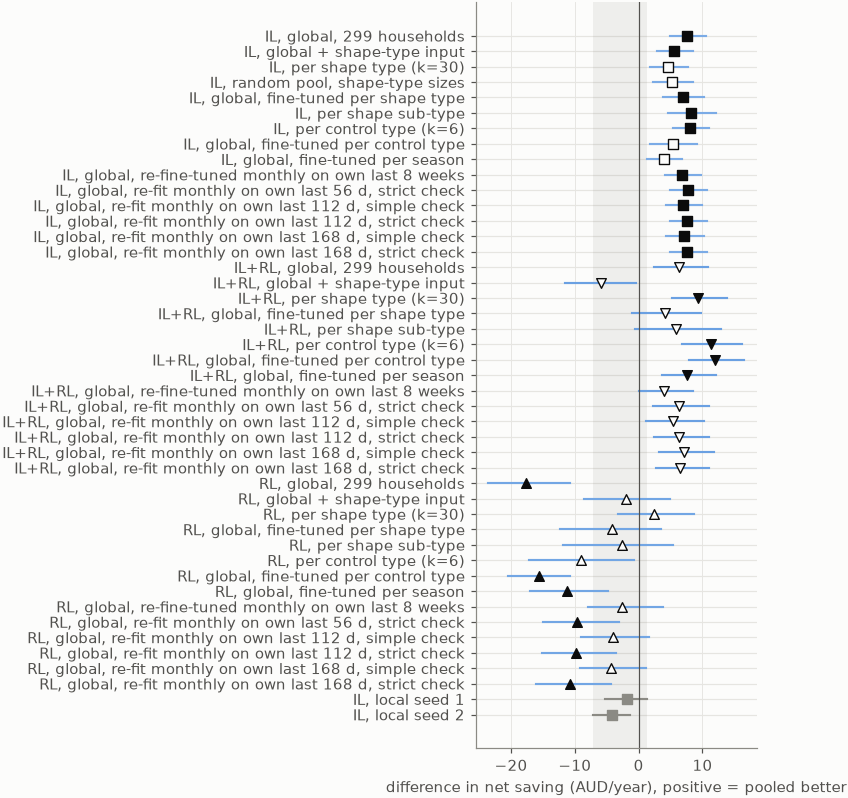

AU
method           scheme  n    mean      lo      hi  pooled better     p  p_holm
    bc           global 30   7.574   4.839  10.605             26 0.000   0.000
    bc     global_typed 30   5.539   2.858   8.529             23 0.001   0.019
    bc             type 30   4.599   1.824   7.662             24 0.003   0.072
    bc        rand_type 30   5.281   2.180   8.594             21 0.007   0.164
    bc        global_ft 30   6.889   3.858  10.224             23 0.000   0.011
    bc          subtype 15   8.201   4.540  12.075             14 0.000   0.006
    bc        ctrl_type 30   7.978   5.307  11.043             26 0.000   0.000
    bc          ctrl_ft 30   5.422   1.855   9.186             20 0.011   0.237
    bc        season_ft 30   3.971   1.308   6.818             19 0.045   0.510
    bc          roll_ft 30   6.784   4.095   9.752             25 0.000   0.000
    bc  roll_w56_strong 30   7.671   4.945  10.696             26 0.000   0.000
    bc   roll_w112_weak 30   6.965   

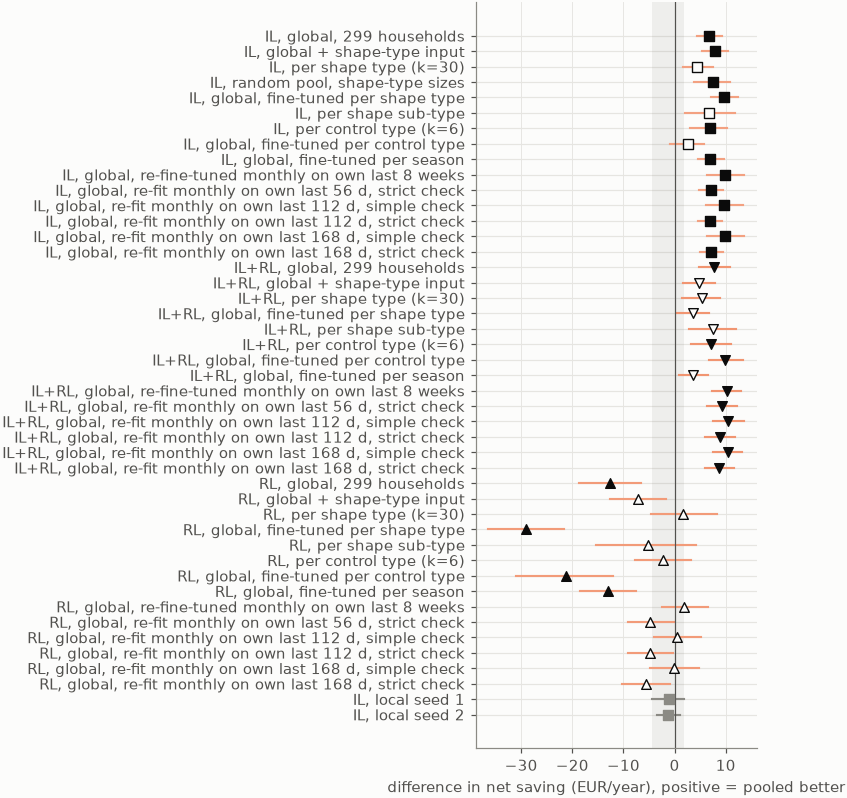

SI
method           scheme  n    mean      lo      hi  pooled better     p  p_holm
    bc           global 30   6.754   4.458   9.225             27 0.000   0.000
    bc     global_typed 30   7.961   5.440  10.506             25 0.000   0.000
    bc             type 30   4.467   1.629   7.488             21 0.013   0.205
    bc        rand_type 30   7.445   3.787  10.757             26 0.000   0.001
    bc        global_ft 30   9.688   7.156  12.351             27 0.000   0.000
    bc          subtype 15   6.717   2.002  11.762             12 0.010   0.185
    bc        ctrl_type 30   6.888   2.964  10.306             27 0.000   0.004
    bc          ctrl_ft 30   2.547  -0.828   5.783             20 0.124   1.000
    bc        season_ft 30   7.016   4.585   9.598             26 0.000   0.000
    bc          roll_ft 30   9.822   6.315  13.520             26 0.000   0.000
    bc  roll_w56_strong 30   7.067   4.834   9.437             28 0.000   0.000
    bc   roll_w112_weak 30   9.607   

In [4]:
# Paired difference in annual net saving, pooled minus local (positive = the
# pooled model saves more), mean over the 30 households with a 95 % bootstrap
# interval. Filled = significant after Holm over every row of the tariff.
#
# The two grey rows are the NOISE FLOOR: the local clone re-trained under seed
# 1 and seed 2, against the published seed-0 clone -- same data, same
# settings, different initialisation. Any row inside their spread is
# indistinguishable from re-rolling the local model.
seeds_local = pd.read_csv(os.path.join(rgg.OUT, "local_seeds.csv"))


def paired_rows(tariff):
    w = (long[long.tariff == tariff]
         .pivot(index="ident", columns="controller", values="saving_annual_net"))
    rows = []
    for m in ("bc", "bc_dqn", "dqn"):
        for s in POOLED:
            c = f"{m}_{s}"
            if c not in w:
                continue
            d = (w[c] - w[f"{m}_fc_h24"]).dropna()
            rows.append({"method": m, "scheme": s, "d": d.to_numpy(),
                         "n": len(d)})
    # Noise floor: saving = -(total cost) with wear zero on every run, so a
    # seed's change in saving is minus its change in the bill.
    sl = seeds_local[(seeds_local.tariff == tariff) & (seeds_local.method == "bc")]
    sw = sl.pivot(index="ident", columns="seed", values="cost_eur_total")
    for s in (1, 2):
        rows.append({"method": "bc", "scheme": f"local seed {s}",
                     "d": -(sw[s] - sw[0]).to_numpy(), "n": len(sw)})
    out = pd.DataFrame(rows)
    out["mean"] = out.d.map(np.mean)
    ci = out.d.map(lambda v: fs.boot_ci(v, stat=np.mean))
    out["lo"], out["hi"] = ci.map(lambda x: x[0]), ci.map(lambda x: x[1])
    out["p"] = out.d.map(lambda v: wilcoxon(v).pvalue if (v != 0).sum() >= 6
                         else np.nan)
    out["p_holm"] = fs.holm(out.p.tolist())
    out["pooled better"] = out.d.map(lambda v: int((v > 0).sum()))
    return out


PAIRED = {t: paired_rows(t) for t in TARIFFS}
for tariff in TARIFFS:
    P = PAIRED[tariff]
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=1.05))
    y = np.arange(len(P))[::-1]
    for yi, (_, r) in zip(y, P.iterrows()):
        noise = r.scheme.startswith("local seed")
        col = MUTED if noise else fs.ctrl_color(tariff, f"{r.method}_x")
        sig = (r.p_holm == r.p_holm) and r.p_holm < 0.05
        ax.plot([r.lo, r.hi], [yi, yi], color=col if not noise else MUTED, lw=1.4)
        ax.scatter([r["mean"]], [yi], marker=fs.FAMILY_MARKER[
                       fs.ctrl_family(f"{r.method}_x")], s=40, zorder=3,
                   facecolor=(INK if sig else SURFACE) if not noise else MUTED,
                   edgecolor=INK if not noise else MUTED, lw=0.9)
    lo_n = P[P.scheme.str.startswith("local seed")][["lo"]].min().iloc[0]
    hi_n = P[P.scheme.str.startswith("local seed")][["hi"]].max().iloc[0]
    ax.axvspan(lo_n, hi_n, color=MUTED, alpha=0.12, lw=0)
    ax.axvline(0, color=INK_2, lw=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{METHOD_NAME[r.method]}, {SCHEME_NAME.get(r.scheme, r.scheme)}"
                        for _, r in P.iterrows()])
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    finish(ax, title=f"{tariff}: pooled minus local, per household",
           xlabel=f"difference in net saving ({hs.money(tariff, 'year')}), "
                  f"positive = pooled better", ylabel="")
    pf.show(fig, f"rlg_paired_vs_local_{tariff.lower()}")
    print(tariff)
    print(P[["method", "scheme", "n", "mean", "lo", "hi", "pooled better",
             "p", "p_holm"]].round(3).to_string(index=False))

## 3. Why localising to the shape types cannot help

Why the per-shape-type models give back the global model's gain:

1. **The shape types do not separate what the dispatch depends on.** The k=30
   clusters leave 86 % of the population's variance in annual load and *more than
   100 %* of the variance in PV and PV/load inside the types — on PV they know
   nothing. That is by construction: each household is normalised by its own
   peak, so the clustering sees when a house uses power, not how much, and never
   sees the roof. The control types (k=6) leave 20 % of the load and 43 % of the
   PV/load variance.
2. **So the type input carries no usable information.** Driving the typed global
   network with a *wrong* shape type changes individual households' bills (mean
   |Δ| 2–19 per year) but not on average (0.3–2.0 per year): the network reacts to
   the input, in no consistent direction.
3. **And a per-type pool is, for the controller, a random sample of ~10
   households.** The random-pool control shows it: pools drawn at random with the
   same sizes score the same as the shape-type pools against the global model (AU
   −2.3 vs −3.0 AUD/a; SI +0.7 vs −2.3 EUR/a). With the tuned clone that deficit is
   small — under the previous settings it was −34 to −36 AUD/a, a cost of the
   smaller pool that the retune has largely removed.
4. **Validation could not have flagged it.** On each household's own 20
   validation weeks every clone — local, per type, global — scores within 0.8 per
   140 days of the others; the 5–10 a year the pooled clones gain appears only in
   the test year (Spearman ρ between the two gaps, for the clone, −0.02 to 0.48). The clones'
   advantage from pooling is robustness to a year the training years did not
   contain, which a held-out week from inside those years cannot measure. For DQN,
   by contrast, validation does see the pooled deficit (ρ up to 0.74).

             shape type (k=30)  control type (k=6)
annual load               0.86                0.20
annual PV                 1.15                1.20
PV / load                 1.09                0.43


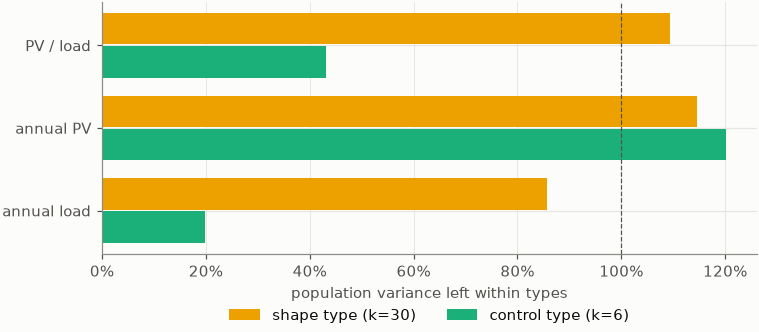

In [5]:
# How much of the variance in what DECIDES a battery's dispatch each typing
# leaves INSIDE its types. 1.0 = the typing knows nothing about that quantity
# (a random split leaves the full variance in every group); 0 = it separates
# households completely. Over the 299 pooled households, training years only.
scale = rgg.household_scale()
scale["shape type (k=30)"] = rgg.population().loc[scale.index, "cluster"]
scale["control type (k=6)"] = rgg.control_types().loc[scale.index, "ctrl_type"]
QTY = {"load_kwh_a": "annual load", "pv_kwh_a": "annual PV",
       "pv_ratio": "PV / load"}
share = pd.DataFrame({typing: {lab: scale.groupby(typing)[q].var().mean()
                                    / scale[q].var() for q, lab in QTY.items()}
                      for typing in ("shape type (k=30)", "control type (k=6)")})
print(share.round(2).to_string())

fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.45))
yy = np.arange(len(share))
for j, (typing, col) in enumerate(zip(share.columns, (SERIES[3], SERIES[2]))):
    ax.barh(yy + (0.2 if j == 0 else -0.2), 100 * share[typing], height=0.38,
            color=col, label=typing)
ax.axvline(100, color=INK_2, lw=0.8, ls="--")   # = what a random split leaves
ax.set_yticks(yy)
ax.set_yticklabels(share.index)
ax.grid(axis="x", color=pf.GRID, lw=0.6)
ax.set_axisbelow(True)
pf.key_legend(ax, ax.get_legend_handles_labels()[0], where="below", ncol=2)
finish(ax, title="What each typing leaves unexplained",
       xlabel="population variance left within types", ylabel="",
       xfmt=PCT)
pf.show(fig, "rlg_type_variance")

In [6]:
# Does the one-hot TYPE input do anything? The seed-0 typed global model is
# driven over the test year twice per household: with its true shape type and
# with a wrong one (cluster + 15). If the network used the input, the wrong
# type would cost money.
wt = rgg.wrong_type_test()
wtp = wt.pivot_table(index=["tariff", "method", "ident"], columns="type_input",
                     values="cost_eur_total")
summary = (wtp["wrong"] - wtp["true"]).groupby(level=[0, 1]).agg(
    mean="mean", abs_mean=lambda v: v.abs().mean(), max_abs=lambda v: v.abs().max())
print("test-year bill, WRONG type minus TRUE type (EUR or AUD / a):")
print(summary.round(2).to_string())

# And could a deployment have seen the pooled-vs-local gap BEFORE the test
# year? Every model, rolled on each household's own validation weeks.
uv = pd.read_csv(rgg.UNIT_VAL)
loc = uv[uv.scheme == "local"].set_index(["tariff", "ident", "method"])["val_net"]
res = rgg.load_results()
res["ident"] = res.ident.astype(int)
m = uv[uv.scheme != "local"].merge(
    res[["tariff", "ident", "scheme", "method", "seed", "cost_eur_total",
         "local_cost_eur_total"]], on=["tariff", "ident", "scheme", "method", "seed"])
m["val_gap"] = m.val_net.values - loc.reindex(
    list(zip(m.tariff, m.ident, m.method))).values
m["test_gap"] = m.cost_eur_total - m.local_cost_eur_total
vt = (m.groupby(["tariff", "method", "scheme"])
      .apply(lambda q: pd.Series({
          "val gap (140 d)": q.val_gap.mean(), "test gap (365 d)": q.test_gap.mean(),
          "rho": spearmanr(q.val_gap, q.test_gap)[0]}), include_groups=False))
print("\npooled minus local cost, validation weeks vs test year "
      "(positive = pooled costs more):")
print(vt.round(2).to_string())

test-year bill, WRONG type minus TRUE type (EUR or AUD / a):
               mean  abs_mean  max_abs
tariff method                         
AU     bc      0.57      2.24    12.77
       bc_dqn  1.24     19.00    70.03
       dqn     1.96     13.04    50.26
SI     bc      0.26      2.07     9.51
       bc_dqn  0.48      2.35     6.49
       dqn     0.99     10.30    38.52

pooled minus local cost, validation weeks vs test year (positive = pooled costs more):
                            val gap (140 d)  test gap (365 d)   rho
tariff method scheme                                               
AU     bc     ctrl_ft                 -0.36             -5.42  0.41
              ctrl_type               -0.07             -7.98 -0.02
              global                   0.02             -7.57  0.39
              global_ft               -0.11             -6.89  0.33
              global_typed             0.33             -5.54  0.48
              rand_type                0.11             -5.28  

## 4. Localising to what the controller cares about

Localised minus **global** (positive = the localisation improves on the global
model it refines), per household. The last row of each method is the deployable
fallback taken one step further: per household, the control-type fine-tune or the
global model, **whichever was cheaper on that household's own validation weeks**.

- **For the clone, localisation adds nothing reliable, and fine-tuning can now
  cost.** AU: per control type +0.4 (n.s.); fine-tuned per control type −2.2
  (p_holm 0.049). SI: fine-tuned per shape type +2.9 (24 of 30, p_holm 0.002), but
  fine-tuned per control type −4.2 (7 of 30, p_holm 0.011). Under the previous
  settings no fine-tune was significantly worse than global; that finding did not
  survive the retune.
- **Restricting the clone's data now costs little**: −3.0 per shape type, −2.3 for
  random pools of the same size, +0.4 per control type on AU (−34 to −36 under the
  previous settings). The tuned clone is far less data-limited.
- **IL+RL gains from control-type localisation on AU** (+4.9 per control type,
  +5.6 fine-tuned, 27 of 30, p_holm ≤ 0.003) and loses from the typed input (−12.3).
- **RL: on AU every localisation beats the global DQN** (+2.1 to +20.1), because
  the global DQN is the weak point (§2). On SI the networks trained on a type's own
  pool beat it (+5.4 to +14.3), while fine-tuning the global DQN in place loses
  (−16.4 per shape type, −8.5 per control type).

So with tuned learners, the answer to "should a controller be localised to its
consumer type" is: for the clone, no — one global network is as good as any
localisation; for reinforcement, train on smaller pools rather than refine a
global network.

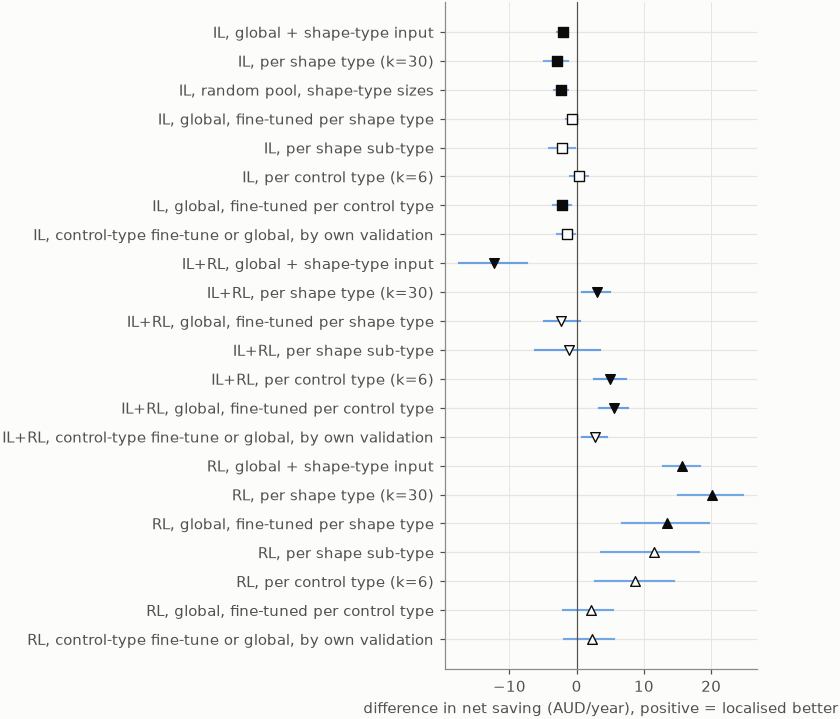

AU
method                                                 row  picked    mean     p  p_holm  better than global
    bc                           global + shape-type input     NaN  -2.035 0.000   0.000                   5
    bc                               per shape type (k=30)     NaN  -2.975 0.001   0.020                   8
    bc                       random pool, shape-type sizes     NaN  -2.293 0.000   0.006                   7
    bc                   global, fine-tuned per shape type     NaN  -0.685 0.164   0.493                  12
    bc                                  per shape sub-type     NaN  -2.155 0.073   0.365                   4
    bc                              per control type (k=6)     NaN   0.404 0.164   0.493                  21
    bc                 global, fine-tuned per control type     NaN  -2.152 0.004   0.049                   7
    bc control-type fine-tune or global, by own validation    21.0  -1.509 0.042   0.252                   6
bc_dqn          

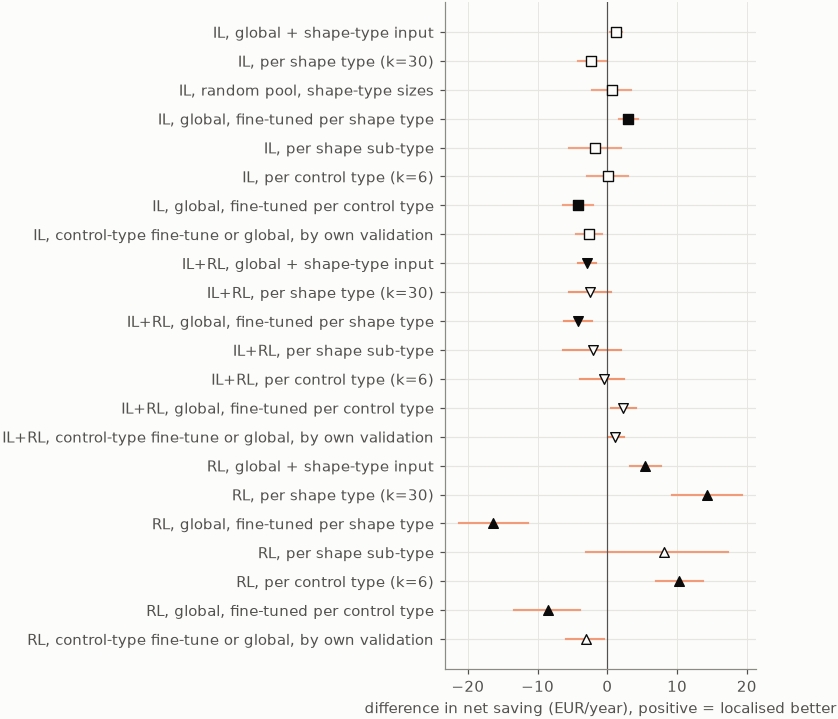

SI
method                                                 row  picked    mean     p  p_holm  better than global
    bc                           global + shape-type input     NaN   1.208 0.015   0.179                  21
    bc                               per shape type (k=30)     NaN  -2.287 0.020   0.216                  10
    bc                       random pool, shape-type sizes     NaN   0.691 0.612   1.000                  16
    bc                   global, fine-tuned per shape type     NaN   2.934 0.000   0.002                  24
    bc                                  per shape sub-type     NaN  -1.807 0.359   1.000                   6
    bc                              per control type (k=6)     NaN   0.134 0.393   1.000                  19
    bc                 global, fine-tuned per control type     NaN  -4.207 0.001   0.011                   7
    bc control-type fine-tune or global, by own validation    20.0  -2.566 0.014   0.179                   5
bc_dqn          

In [7]:
# Localised minus GLOBAL (positive = the localisation saves more than the
# global model it is meant to improve on), per household, seeds of the global
# model averaged. The last row per method is the deployable fallback: per
# household, the control-type fine-tune or the global model, whichever was
# cheaper on that household's OWN validation weeks -- a choice made without
# the test year.
def vs_global(tariff):
    w = (long[long.tariff == tariff]
         .pivot(index="ident", columns="controller", values="saving_annual_net"))
    v = uv[(uv.tariff == tariff)]
    rows = []
    for meth in ("bc", "bc_dqn", "dqn"):
        g = w[f"{meth}_global"]
        for s in ("global_typed", "type", "rand_type", "global_ft", "subtype",
                  "ctrl_type", "ctrl_ft"):
            c = f"{meth}_{s}"
            if c in w:
                d = (w[c] - g).dropna()
                rows.append({"method": meth, "row": SCHEME_NAME[s], "d": d})
        # The guarded choice, household by household.
        vg = v[(v.scheme == "global") & (v.method == meth)].groupby("ident").val_net.mean()
        vf = v[(v.scheme == "ctrl_ft") & (v.method == meth)].set_index("ident").val_net
        if len(vf):
            pick_ft = (vf < vg.reindex(vf.index))
            chosen = w[f"{meth}_ctrl_ft"].where(pick_ft.reindex(w.index), g)
            rows.append({"method": meth, "row": "control-type fine-tune or global, "
                         "by own validation", "d": (chosen - g).dropna(),
                         "picked": int(pick_ft.sum())})
    out = pd.DataFrame(rows)
    out["mean"] = out.d.map(np.mean)
    out["p"] = out.d.map(lambda v: wilcoxon(v).pvalue if (v != 0).sum() >= 6 else np.nan)
    out["p_holm"] = fs.holm(out.p.tolist())
    out["better than global"] = out.d.map(lambda v: int((v > 0).sum()))
    return out


for tariff in TARIFFS:
    V = vs_global(tariff)
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.95))
    y = np.arange(len(V))[::-1]
    for yi, (_, r) in zip(y, V.iterrows()):
        lo, hi = fs.boot_ci(r.d.to_numpy(), stat=np.mean)
        sig = (r.p_holm == r.p_holm) and r.p_holm < 0.05
        ax.plot([lo, hi], [yi, yi], color=fs.ctrl_color(tariff, f"{r.method}_x"), lw=1.4)
        ax.scatter([r["mean"]], [yi], marker=fs.FAMILY_MARKER[fs.ctrl_family(f"{r.method}_x")],
                   s=40, zorder=3, facecolor=INK if sig else SURFACE, edgecolor=INK, lw=0.9)
    ax.axvline(0, color=INK_2, lw=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{METHOD_NAME[r.method]}, {r.row}" for _, r in V.iterrows()])
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    finish(ax, title=f"{tariff}: localised minus global, per household",
           xlabel=f"difference in net saving ({hs.money(tariff, 'year')}), "
                  f"positive = localised better", ylabel="")
    pf.show(fig, f"rlg_localised_vs_global_{tariff.lower()}")
    print(tariff)
    print(V.drop(columns="d").round(3).to_string(index=False))

## 5. Localising in time

The network already reads time as **input** (hour of day, weekday and day of year,
as sin/cos), so the question here is localisation in time by **data**, done as a
fine-tune of the global network, for all three methods, each from all three global
seeds:

- **per season** — the global network fine-tuned on all 299 households'
  training days of one meteorological season (DJF/MAM/JJA/SON), validated on that
  season's held-out weeks, with the fallback guard; the four networks are
  switched at the season boundary.
- **monthly, on the household's own recent past** — at the start of every
  test-year month the global network is fine-tuned on that household's last 8
  weeks; causal by construction, everything it learns from is in the past when
  the month starts. IL re-clones a MILP solved on those 8 weeks alone (with the
  tuned clone optimiser); RL and IL+RL take 40k reinforcement steps on the first 7
  weeks, validate on the last, and keep the parent unless they beat it there
  (IL+RL is held to that month's re-cloned network).

Each is compared with the **exact network it started from**, seed by seed. The
test of an effect here is that it has the same sign from every parent.

| same sign from all three parents? | AU | SI |
|---|---|---|
| IL, monthly | yes, small **loss**: −1.4 / −0.7 / −0.2, mean −0.8 AUD/a | **yes, gain**: +4.1 / +2.4 / +2.7, mean +3.1 EUR/a |
| IL+RL, monthly | yes, **loss**: −2.2 / −4.6 / −0.2, mean −2.3 | no: −0.2 / +5.6 / +2.0 |
| RL, monthly | **yes, gain**: +11.6 / +22.7 / +11.2, mean +15.2 | **yes, gain**: +27.0 / +7.2 / +9.4, mean +14.5 |
| IL, per season | yes, **loss**: −5.6 / −2.0 / −3.1, mean −3.6 | no: −0.1 / +1.0 / −0.0 |
| IL+RL, per season | no: +2.0 / +2.1 / −0.4 | no: −8.0 / +4.1 / −8.2 |
| RL, per season | **yes, gain**: +3.2 / +7.0 / +9.1, mean +6.4 | no: +11.1 / −8.4 / −3.6 |

**What it is doing: repair.** The gains land on the weak starting networks. The gain
from the monthly re-fit falls the better the parent already was (Spearman ρ between
the parent's standing against local and its gain: −0.98 AU, −0.87 SI over the nine
method × seed parents; per season −0.48 / −0.20, n.s.). The global DQN is the weakest
parent in the study (§2), and re-fitting it monthly on the household's own data
recovers +15 a year on both tariffs — which brings it to 233 AUD/a and 49 EUR/a,
level with the local DQN (235.5 / 47.0). The clone, already strong, has
little to repair: monthly re-fits cost it slightly on AU and gain 3 EUR/a on SI.

This **reverses** the previous settings' result for RL, where the monthly re-fit
lost 15.6 AUD/a from every parent: the tuned DQN (lower learning rate, longer
episodes) over-fits a 7-week window far less.

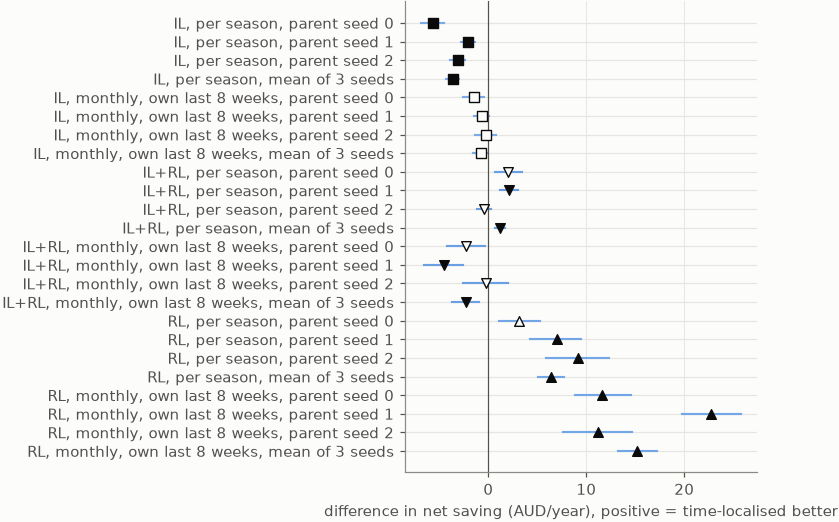

AU
method                                        row    mean      p  p_holm  better than parent
    bc                  per season, parent seed 0 -5.6177 0.0000  0.0000                   0
    bc                  per season, parent seed 1 -2.0492 0.0000  0.0000                   3
    bc                  per season, parent seed 2 -3.1415 0.0000  0.0000                   0
    bc                per season, mean of 3 seeds -3.6028 0.0000  0.0000                   0
    bc   monthly, own last 8 weeks, parent seed 0 -1.4453 0.0099  0.0894                   9
    bc   monthly, own last 8 weeks, parent seed 1 -0.6751 0.1706  0.5118                  14
    bc   monthly, own last 8 weeks, parent seed 2 -0.2492 0.7611  1.0000                  13
    bc monthly, own last 8 weeks, mean of 3 seeds -0.7899 0.0120  0.0894                   6
bc_dqn                  per season, parent seed 0  1.9762 0.0106  0.0894                  22
bc_dqn                  per season, parent seed 1  2.0722 0.0001  0

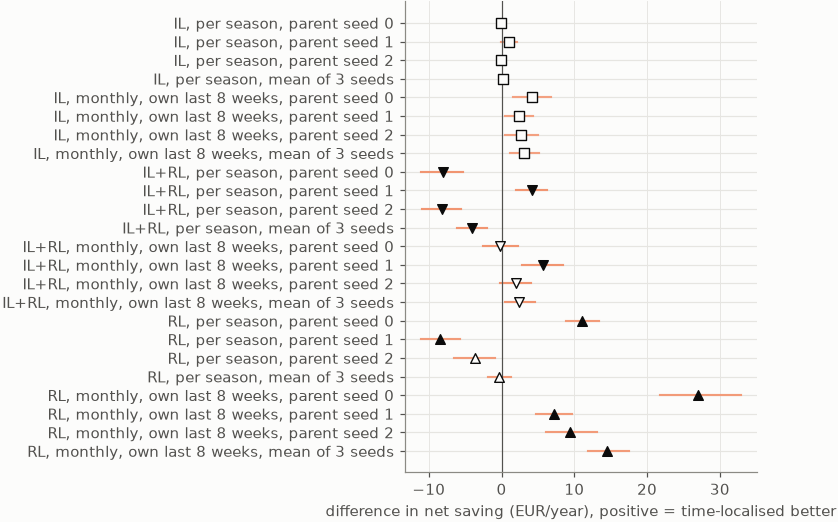

SI
method                                        row    mean      p  p_holm  better than parent
    bc                  per season, parent seed 0 -0.1411 0.0185  0.1853                   6
    bc                  per season, parent seed 1  0.9621 0.2710  1.0000                  17
    bc                  per season, parent seed 2 -0.0361 0.5561  1.0000                  14
    bc                per season, mean of 3 seeds  0.2616 0.7766  1.0000                  15
    bc   monthly, own last 8 weeks, parent seed 0  4.1332 0.0093  0.1116                  22
    bc   monthly, own last 8 weeks, parent seed 1  2.3841 0.0364  0.3279                  19
    bc   monthly, own last 8 weeks, parent seed 2  2.6869 0.0473  0.3781                  19
    bc monthly, own last 8 weeks, mean of 3 seeds  3.0681 0.0081  0.1059                  19
bc_dqn                  per season, parent seed 0 -8.0309 0.0000  0.0000                   3
bc_dqn                  per season, parent seed 1  4.1206 0.0017  0

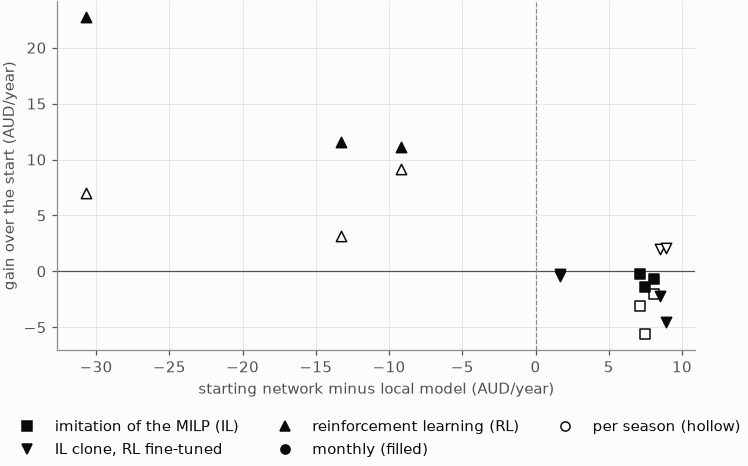

SI monthly, own recent data: Spearman(parent vs local, gain) = -0.87 (p 0.002)
SI per season: Spearman(parent vs local, gain) = -0.20 (p 0.606)


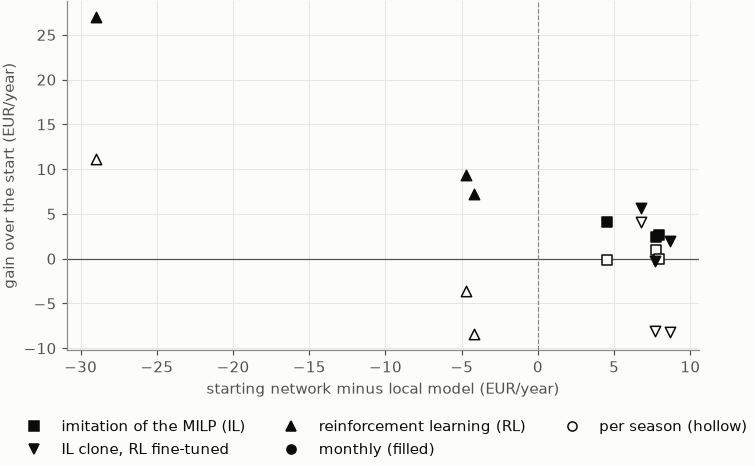

AU monthly fine-tunes that kept the parent: 468 of 3240; mean held-out agreement with the window's MILP 0.854
AU seasonal fine-tunes that kept the parent, per method: bc: []; bc_dqn: ['DJF']; dqn: ['DJF', 'SON']
SI monthly fine-tunes that kept the parent: 394 of 3240; mean held-out agreement with the window's MILP 0.823
SI seasonal fine-tunes that kept the parent, per method: bc: ['JJA', 'MAM']; bc_dqn: ['DJF', 'MAM']; dqn: ['JJA']


In [8]:
# Each time-localised controller against the EXACT network it was fine-tuned
# from (positive = the localisation saves more), so a weak or strong parent
# cannot pass for an effect of localising. The seasonal fine-tunes start from
# the seed-0 global network; the rolling fine-tunes were run from each of the
# three global seeds and are compared seed for seed, then averaged.
res = rgg.load_results()
res["ident"] = res.ident.astype(int)


def vs_parent(tariff):
    x = res[res.tariff == tariff].pivot_table(
        index="ident", columns=["scheme", "method", "seed"], values="cost_eur_total")
    rows = []
    NAME = {"season_ft": "per season", "roll_ft": "monthly, own last 8 weeks"}
    for m in ("bc", "bc_dqn", "dqn"):
        for scheme, nm in NAME.items():
            seeds = [s for s in (0, 1, 2) if (scheme, m, s) in x]
            for s in seeds:
                rows.append({"method": m, "row": f"{nm}, parent seed {s}",
                             "d": -(x[(scheme, m, s)] - x[("global", m, s)])})
            if len(seeds) > 1:
                rows.append({"method": m, "row": f"{nm}, mean of {len(seeds)} seeds",
                             "d": sum(-(x[(scheme, m, s)] - x[("global", m, s)])
                                      for s in seeds) / len(seeds)})
    out = pd.DataFrame(rows)
    out["mean"] = out.d.map(np.mean)
    out["p"] = out.d.map(lambda v: wilcoxon(v).pvalue)
    out["p_holm"] = fs.holm(out.p.tolist())
    out["better than parent"] = out.d.map(lambda v: int((v > 0).sum()))
    return out


for tariff in TARIFFS:
    V = vs_parent(tariff)
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.70))
    y = np.arange(len(V))[::-1]
    for yi, (_, r) in zip(y, V.iterrows()):
        lo, hi = fs.boot_ci(r.d.to_numpy(), stat=np.mean)
        sig = r.p_holm < 0.05
        ax.plot([lo, hi], [yi, yi], color=fs.ctrl_color(tariff, f"{r.method}_x"), lw=1.4)
        ax.scatter([r["mean"]], [yi], marker=fs.FAMILY_MARKER[fs.ctrl_family(f"{r.method}_x")],
                   s=40, zorder=3, facecolor=INK if sig else SURFACE, edgecolor=INK, lw=0.9)
    ax.axvline(0, color=INK_2, lw=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{METHOD_NAME[r.method]}, {r.row}" for _, r in V.iterrows()])
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    finish(ax, title=f"{tariff}: localised in time minus the network it started from",
           xlabel=f"difference in net saving ({hs.money(tariff, 'year')}), "
                  f"positive = time-localised better", ylabel="")
    pf.show(fig, f"rlg_time_vs_parent_{tariff.lower()}")
    print(tariff)
    print(V.drop(columns="d").round(4).to_string(index=False))

# Is time-localisation a gain, or a REPAIR of a weak starting network? Each
# point is one (scheme, method, seed): x = how its parent stood against the
# local model, y = what localising in time added to that parent.
gain_rows = []
for tariff in TARIFFS:
    x = res[res.tariff == tariff].pivot_table(
        index="ident", columns=["scheme", "method", "seed"], values="cost_eur_total")
    loc = (res[(res.tariff == tariff) & (res.scheme == "global") & (res.seed == 0)]
           .pivot_table(index="ident", columns="method", values="local_cost_eur_total"))
    for sch in ("season_ft", "roll_ft"):
        for m in ("bc", "bc_dqn", "dqn"):
            for sd in (0, 1, 2):
                if (sch, m, sd) in x:
                    gain_rows.append({
                        "tariff": tariff, "scheme": sch, "method": m, "seed": sd,
                        "parent_vs_local": -(x[("global", m, sd)] - loc[m]).mean(),
                        "gain": -(x[(sch, m, sd)] - x[("global", m, sd)]).mean()})
G = pd.DataFrame(gain_rows)
for tariff in TARIFFS:
    q = G[G.tariff == tariff]
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.62))
    for _, r in q.iterrows():
        ax.scatter(r.parent_vs_local, r.gain, s=46, lw=1.0,
                   marker=fs.FAMILY_MARKER[fs.ctrl_family(f"{r.method}_x")],
                   facecolor=INK if r.scheme == "roll_ft" else SURFACE,
                   edgecolor=INK, zorder=3)
    ax.axhline(0, color=INK_2, lw=0.8)
    ax.axvline(0, color=MUTED, lw=0.8, ls="--")
    for sch, lab in (("roll_ft", "monthly, own recent data"), ("season_ft", "per season")):
        rho, p = spearmanr(q[q.scheme == sch].parent_vs_local, q[q.scheme == sch].gain)
        print(f"{tariff} {lab}: Spearman(parent vs local, gain) = {rho:+.2f} (p {p:.3f})")
    pf.key_legend(ax, [Line2D([], [], marker=fs.FAMILY_MARKER[f], ls="", color=INK,
                              label=fs.FAMILY_LABEL[f]) for f in ("IL", "IL+RL", "RL")]
                  + [Line2D([], [], marker="o", ls="", color=INK, label="monthly (filled)"),
                     Line2D([], [], marker="o", ls="", mfc=SURFACE, color=INK,
                            label="per season (hollow)")], where="below", ncol=3)
    ax.grid(color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    finish(ax, title=f"{tariff}: what localising in time adds, by how good the start was",
           xlabel=f"starting network minus local model ({hs.money(tariff, 'year')})",
           ylabel=f"gain over the start ({hs.money(tariff, 'year')})")
    pf.show(fig, f"rlg_time_repair_{tariff.lower()}")

# How often the guards handed the parent back unchanged.
for t in TARIFFS:
    q = res[(res.tariff == t) & (res.scheme == "roll_ft")]
    print(f"{t} monthly fine-tunes that kept the parent: "
          f"{int(q.months_kept_parent.sum())} of {int(q.n_months.sum())}; "
          f"mean held-out agreement with the window's MILP {q.mean_holdout_agreement.mean():.3f}")
    sq = res[(res.tariff == t) & (res.scheme == "season_ft")]
    if len(sq):
        kp = sq[sq.seed == 0].groupby("method").kept_parent.first()
        print(f"{t} seasonal fine-tunes that kept the parent, per method: "
              + "; ".join(f"{m}: {sorted(k for k, v in d.items() if v)}" for m, d in kp.items()))

### 5b. The monthly re-fit: a longer window, a stricter check

The window × check grid — **window** 56 / 112 / 168 days × **check** simple / strict,
every method, every global seed, 3,240 household-years:

- **window** — how many trailing days the month learns from. Longer = more data,
  but older.
- **simple check**: the last 7 days of the window both pick the training checkpoint
  and decide whether the fine-tune replaces its parent — one week, used twice, so
  the decision is biased towards the fine-tune.
- **strict check**: the window is cut into three disjoint parts — train, a 7-day
  week that picks the checkpoint, and the final **14 days that nothing was
  trained, stopped or labelled on** (for IL and IL+RL the month's MILP teacher is
  solved without them). The fine-tune replaces its parent only if it is cheaper
  on those 14 days, day by day, at one-sided paired Wilcoxon p < 0.10.

What the grid shows (gain over the exact starting network, 3-seed mean; the table
below has every cell and each seed):

- **The strict check now mostly costs gains.** It keeps the parent in 93–98 % of
  months for the clones and 70–82 % for RL. RL's gains roughly halve under it (AU
  +15.2 / +13.6 / +13.4 simple → +8.1 / +7.8 / +7.0 strict for 56 / 112 / 168 d; SI
  +14.5 / +13.0 / +12.5 → +7.9 / +7.7 / +6.9), all from every parent. The clones'
  small effects shrink towards zero (AU IL −0.8 → +0.1; SI IL +3.1 → +0.3). Under
  the previous settings the strict check was what removed RL's losses; with the
  tuned DQN there are no losses to remove.
- **The window makes little difference** for any method on either tariff (within
  ~3 a year across 56–168 d).
- **One place the strict check is the better choice**: SI IL+RL, where it gives a
  small gain consistent across all three parents (+1.0 to +1.6 EUR/a, p_holm ≤
  0.006) where the simple check's larger mean (+2.5–2.8) is not significant after
  Holm (p_holm 0.06–0.18) and, at 56 d, not consistent across parents.

**So:** for RL, the simple check — the re-fit repairs the weak global DQN and the
tuned learner does not run away on 7 weeks. For the clone, no monthly re-fit on AU;
the simple check on SI (+3 EUR/a). The best learned controllers in the study are the
global clone (AU 268.9 AUD/a, 94.7 % of the MILP; its per-control-type variant
269.3) and the global clone re-fitted monthly on SI (64.3 EUR/a, 59 % of the MILP;
best rule 72.2).

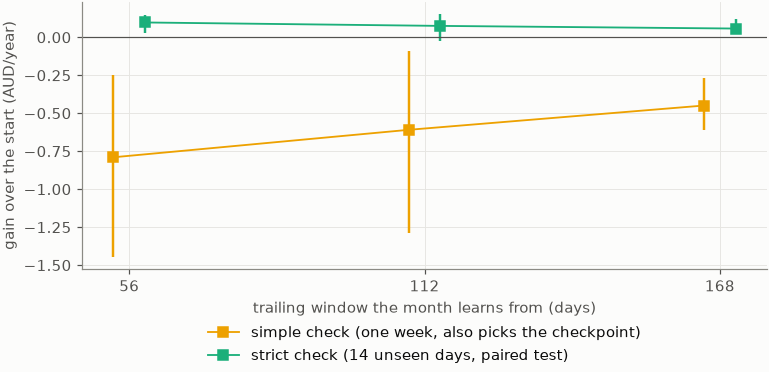

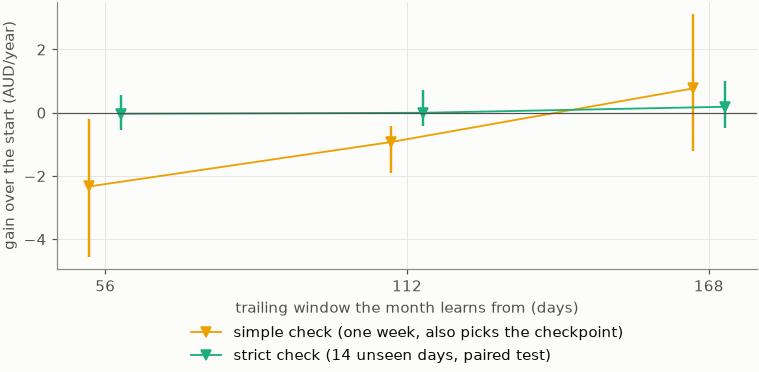

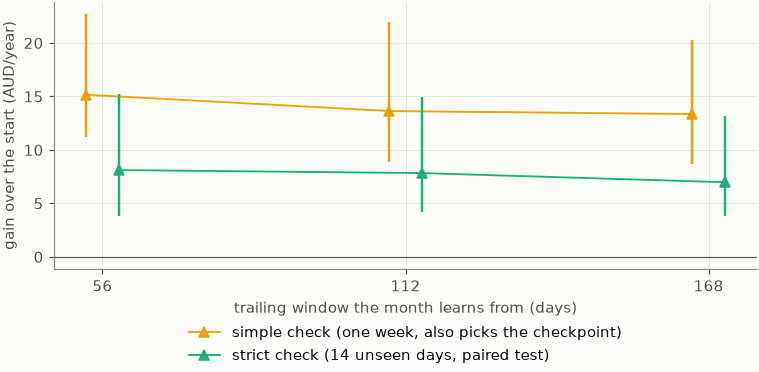

AU
method  window  check  seed 0  seed 1  seed 2   mean  same sign  p (seed mean)  better hh  months kept parent  p_holm
    bc      56   weak  -1.445  -0.675  -0.249 -0.790       True          0.012          6               0.060   0.120
    bc      56 strong   0.030   0.116   0.147  0.098       True          0.001         15               0.972   0.012
    bc     112   weak  -1.285  -0.452  -0.090 -0.609       True          0.129         11               0.065   0.647
    bc     112 strong  -0.022   0.093   0.154  0.075      False          0.017         12               0.979   0.154
    bc     168   weak  -0.612  -0.469  -0.266 -0.449       True          0.067         10               0.060   0.467
    bc     168 strong   0.025   0.122   0.026  0.058       True          0.021         15               0.974   0.165
bc_dqn      56   weak  -2.236  -4.557  -0.202 -2.331       True          0.005         10               0.277   0.051
bc_dqn      56 strong  -0.532  -0.139   0.573 -0.033 

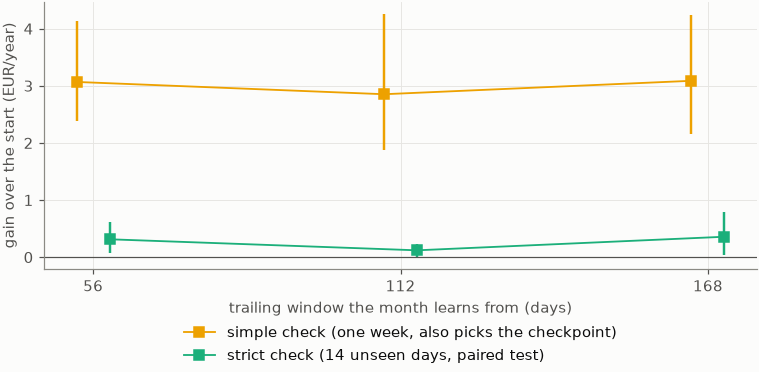

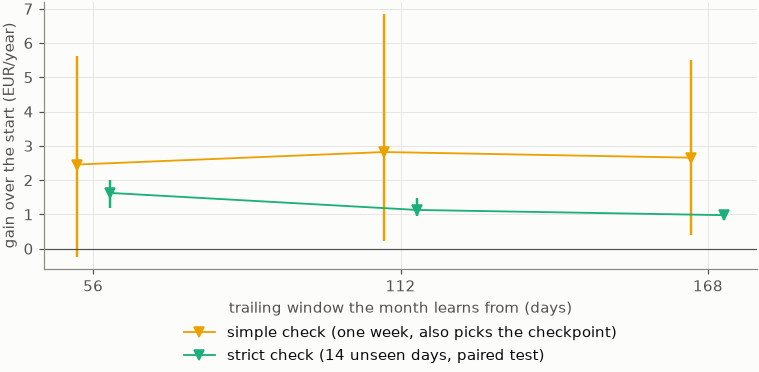

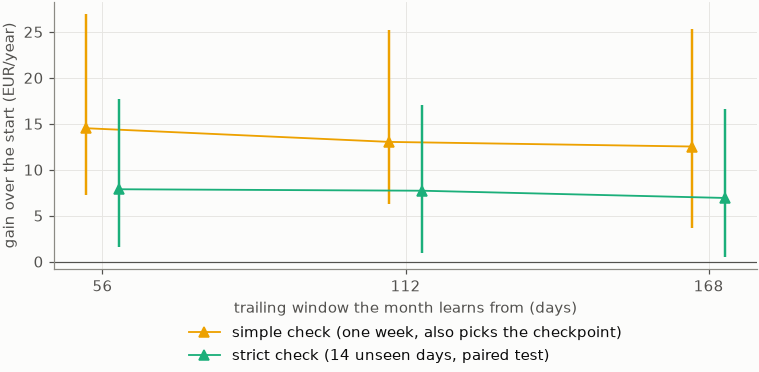

SI
method  window  check  seed 0  seed 1  seed 2   mean  same sign  p (seed mean)  better hh  months kept parent  p_holm
    bc      56   weak   4.133   2.384   2.687  3.068       True          0.008         19               0.051   0.057
    bc      56 strong   0.249   0.067   0.623  0.313       True          0.079         10               0.955   0.182
    bc     112   weak   4.260   1.884   2.415  2.853       True          0.014         22               0.049   0.068
    bc     112 strong   0.233   0.006   0.121  0.120       True          0.326          8               0.961   0.326
    bc     168   weak   4.243   2.867   2.154  3.088       True          0.005         20               0.048   0.039
    bc     168 strong   0.245   0.042   0.785  0.358       True          0.004         12               0.960   0.039
bc_dqn      56   weak  -0.238   5.630   1.970  2.454      False          0.061         17               0.207   0.182
bc_dqn      56 strong   1.183   1.696   2.002  1.627 

In [9]:
# Every (window, check) cell of the monthly re-fit, against the exact network
# it started from, three seeds each. The line is the 3-seed mean, the bar the
# range of the three seeds -- a bar that crosses zero is an effect that one
# parent shows and another does not.
def grid_rows(tariff):
    x = res[res.tariff == tariff].pivot_table(
        index="ident", columns=["scheme", "method", "seed"], values="cost_eur_total")
    rows = []
    for m in ("bc", "bc_dqn", "dqn"):
        for w, g in ROLL_GRID:
            sch = rgg.roll_scheme(w, g)
            per = [-(x[(sch, m, sd)] - x[("global", m, sd)]) for sd in (0, 1, 2)
                   if (sch, m, sd) in x]
            if len(per) < 3:
                continue
            mean = sum(per) / 3
            q = res[(res.tariff == tariff) & (res.scheme == sch) & (res.method == m)]
            rows.append({"method": m, "window": w, "check": g,
                         "seed 0": per[0].mean(), "seed 1": per[1].mean(),
                         "seed 2": per[2].mean(), "mean": mean.mean(),
                         "same sign": len({np.sign(round(v.mean(), 6)) for v in per}) == 1,
                         "p (seed mean)": wilcoxon(mean).pvalue,
                         "better hh": int((mean > 0).sum()),
                         "months kept parent": q.months_kept_parent.sum() / q.n_months.sum()})
    out = pd.DataFrame(rows)
    out["p_holm"] = fs.holm(out["p (seed mean)"].tolist())
    return out


GRID = {t: grid_rows(t) for t in TARIFFS}
for tariff in TARIFFS:
    Gt = GRID[tariff]
    for m in ("bc", "bc_dqn", "dqn"):
        q = Gt[Gt.method == m]
        if q.empty:
            continue
        fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.50))
        for g, col, off in (("weak", SERIES[3], -3), ("strong", SERIES[2], +3)):
            r = q[q.check == g].sort_values("window")
            lo = r[["seed 0", "seed 1", "seed 2"]].min(axis=1)
            hi = r[["seed 0", "seed 1", "seed 2"]].max(axis=1)
            ax.vlines(r.window + off, lo, hi, color=col, lw=1.6)
            ax.plot(r.window + off, r["mean"], marker=fs.FAMILY_MARKER[fs.ctrl_family(f"{m}_x")],
                    color=col, lw=1.2, ms=7,
                    label="simple check (one week, also picks the checkpoint)" if g == "weak"
                    else "strict check (14 unseen days, paired test)")
        ax.axhline(0, color=INK_2, lw=0.8)
        ax.set_xticks(list(rgg.ROLL_WINDOWS))
        ax.grid(color=pf.GRID, lw=0.6)
        ax.set_axisbelow(True)
        pf.key_legend(ax, ax.get_legend_handles_labels()[0], where="below", ncol=1)
        finish(ax, title=f"{tariff}, {METHOD_NAME[m]}: monthly re-fit by window and check",
               xlabel="trailing window the month learns from (days)",
               ylabel=f"gain over the start ({hs.money(tariff, 'year')})")
        pf.show(fig, f"rlg_roll_grid_{tariff.lower()}_{m}")
    print(tariff)
    print(Gt.round(3).to_string(index=False))

## 6. What this does and does not show

- **Shown (under the tuned settings):** pooling households still helps the clone —
  modestly on AU (+5 to +8 AUD/a, since the retune made the local clone much
  stronger) and as much as before on SI (+7 to +10 EUR/a); the gain survives three
  seeds and a seed-noise floor. On AU the pooled clones beat the best rule (269 vs
  264.5 AUD/a, 25–27 of 30). Localising the clone, by type or by fine-tune, adds
  nothing reliable and sometimes costs; the study's shape clusters are not
  control-relevant. Pooled pure RL loses to local RL, and is best repaired by a
  monthly re-fit on the household's own recent data (+15 a year on both tariffs).
  Per-season fine-tuning helps nowhere for the clone.
- **What the retune changed.** Under the previous settings this notebook found a
  large AU pooling gain for the clone (+30 AUD/a), a large cost of training on small
  pools (−34 to −36), that localisation by fine-tuning was never worse than global,
  and that a monthly RL re-fit lost money. None of those survived: they were
  properties of under-tuned learners, not of pooling or localisation.
- **Not shown:** that pooled pure RL can match local RL — it runs on
  hyperparameters tuned for the *local* learner, and a pooled search was not done.
  Every scheme except the global ones, the shape-type clone, the seasonal and the
  monthly ones is one seed. SI training
  is blind to the contract standing charge, which caps every learned SI result below
  the peak-shaving rule regardless of pooling.
- **Selection.** The best rule and the best realistic MPC are chosen ex post on
  the test year, which favours them; no learned scheme was chosen on the test year
  (the fallback row selects on validation only). The hyperparameters were chosen on
  non-study households' validation weeks.
- **Reproduce:** `python3 run_rl_global.py --phase cache|train|eval|report` with
  `--schemes`, `--seed`; `rgg.unit_validation()`, `rgg.local_seed_runs()`,
  `rgg.wrong_type_test()` for §2–§4; `--schemes season_ft [--seed s]` for the
  seasonal fine-tunes and `rgg.run_roll_grid([(window, guard), ...])` for every
  monthly re-fit, `roll_ft` = (56, weak) included (§5, §5b). Everything is cached by
  digest.